# Notebook 4: Analyze Xenium-Style Single-Cell Spatial Data
## Single-Cell Resolution Spatial Transcriptomics

**Dataset:** Xenium Human Lung Cancer (loaded via squidpy)  
**Tools:** Scanpy, Squidpy, Seaborn, Matplotlib

### What is Xenium?
Xenium is fundamentally different from Visium:

| Feature | Visium | Xenium |
|---|---|---|
| Resolution | ~55µm spots (multiple cells per spot) | Single-cell (each cell individually segmented) |
| Method | Captures RNA from spots on slide | In-situ sequencing (RNA detected inside cells) |
| Gene panel | Whole transcriptome | Targeted panel (~300-500 genes) |
| Output | Spot × gene matrix | Cell × gene matrix |

Xenium gives true **single-cell resolution** — we know the gene expression of each individual cell AND its exact position in the tissue.

## Step 1: Install Required Packages

In [1]:
!pip install -q scanpy squidpy igraph leidenalg seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## Step 2: Import Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.1


## Step 3: Load the Dataset

We use Squidpy's built-in **Imaging Mass Cytometry (IMC)** dataset. Like Xenium, this is a **single-cell resolution** spatial dataset — each row is one individual cell with its spatial coordinates. This lets us demonstrate the exact same analysis pipeline used for Xenium data.

The dataset contains:
- Single cells from breast cancer tissue
- Spatial coordinates for each cell
- Pre-annotated cell type clusters

`sq.datasets.imc()` downloads and loads the data automatically into an `AnnData` object.

In [3]:
adata = sq.datasets.imc()
print(adata)
print(f"\nNumber of cells: {adata.n_obs}")
print(f"Number of markers/genes: {adata.n_vars}")
print(f"\nCell metadata columns: {list(adata.obs.columns)}")

INFO     Downloading imc.h5ad from https://exampledata.scverse.org/squidpy/figshare/imc.h5ad                       


  0%|                                              | 0.00/1.57M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 4668 × 34
    obs: 'cell type'
    uns: 'cell type_colors'
    obsm: 'spatial'

Number of cells: 4668
Number of markers/genes: 34

Cell metadata columns: ['cell type']


## Step 4: Inspect Spatial Coordinates

The spatial coordinates of each cell are stored in `adata.obsm['spatial']`. This is a 2D array where each row is a cell and the two columns are the x and y coordinates in the tissue.

In [4]:
print("Spatial coordinates (first 5 cells):")
print(adata.obsm["spatial"][:5])
print(f"\nSpatial array shape: {adata.obsm['spatial'].shape}")

Spatial coordinates (first 5 cells):
[[  1.70909091  15.32727273]
 [  3.84946237  42.07526882]
 [  0.86666667  50.33333333]
 [  1.38888889 133.77777778]
 [  2.10714286 199.66071429]]

Spatial array shape: (4668, 2)


## Step 5: Calculate Quality Control Metrics

We calculate QC metrics for each cell:
- `total_counts`: total expression per cell
- `n_genes_by_counts`: number of unique markers detected

These help identify and remove poor quality cells before analysis.

In [6]:
# Calculate QC metrics - compatible fix
adata.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata, percent_top=None, inplace=True)
print("QC metrics calculated!")
print(f"Total cells: {adata.n_obs}")

QC metrics calculated!
Total cells: 4668


## Step 6: Plot QC Distributions

We plot distributions to understand data quality and guide filtering:
1. **Total counts per cell**: How much expression was detected per cell
2. **Unique markers per cell**: How many different proteins/genes detected
3. **Log total counts**: Log-scale view of expression levels
4. **Counts distribution**: Overall spread of expression values

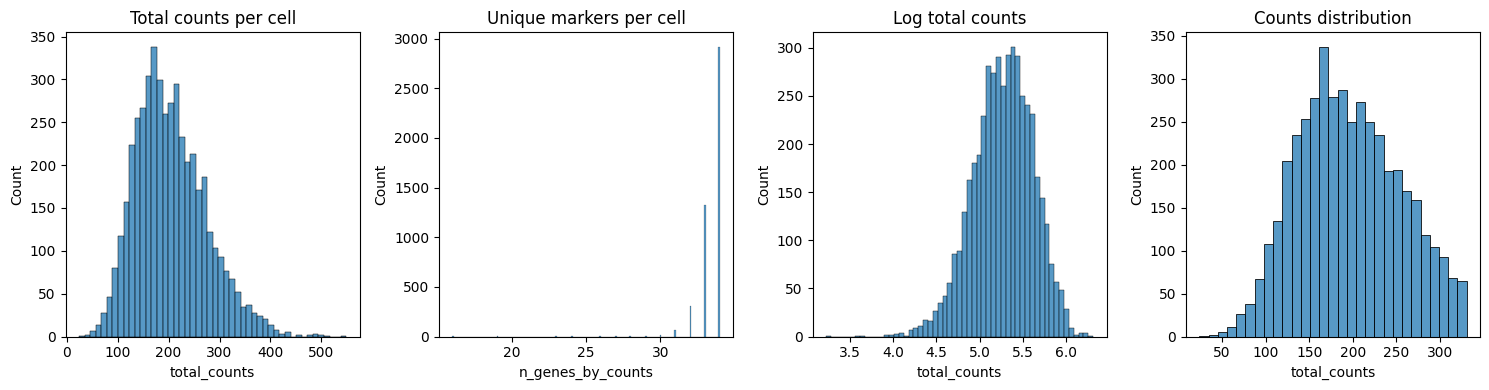

Saved: qc_histograms_xenium.jpeg


In [7]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total counts per cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

axs[1].set_title("Unique markers per cell")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])

axs[2].set_title("Log total counts")
sns.histplot(np.log1p(adata.obs["total_counts"]), kde=False, ax=axs[2])

axs[3].set_title("Counts distribution")
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < adata.obs["total_counts"].quantile(0.95)],
    kde=False, ax=axs[3]
)

plt.tight_layout()
plt.savefig("qc_histograms_xenium.jpeg", dpi=150)
plt.show()
print("Saved: qc_histograms_xenium.jpeg")

## Step 7: Filter Cells and Genes

We filter out low-quality cells and rarely detected genes:
- `min_counts=10`: Remove cells with very low total expression
- `min_cells=5`: Remove markers detected in very few cells

In [8]:
print(f"Before filtering: {adata.n_obs} cells, {adata.n_vars} markers")
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)
print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} markers")

Before filtering: 4668 cells, 34 markers
After filtering: 4668 cells, 34 markers


## Step 8: Normalize, Reduce Dimensions and Cluster

Standard preprocessing pipeline:
- **normalize_total()**: Scale each cell to the same total expression
- **log1p()**: Log-transform to compress the scale
- **pca()**: Reduce to principal components
- **neighbors()**: Build cell similarity graph
- **umap()**: 2D embedding for visualization
- **leiden()**: Cluster cells by transcriptional similarity

In [9]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", directed=False, n_iterations=2)
print(f"Found {len(adata.obs['leiden'].unique())} Leiden clusters")

Found 15 Leiden clusters


## Step 9: Visualize Clusters on UMAP

UMAP plot colored by total counts, unique genes, and Leiden clusters. In a good analysis, the cluster structure should reflect biology, not technical factors like total counts.

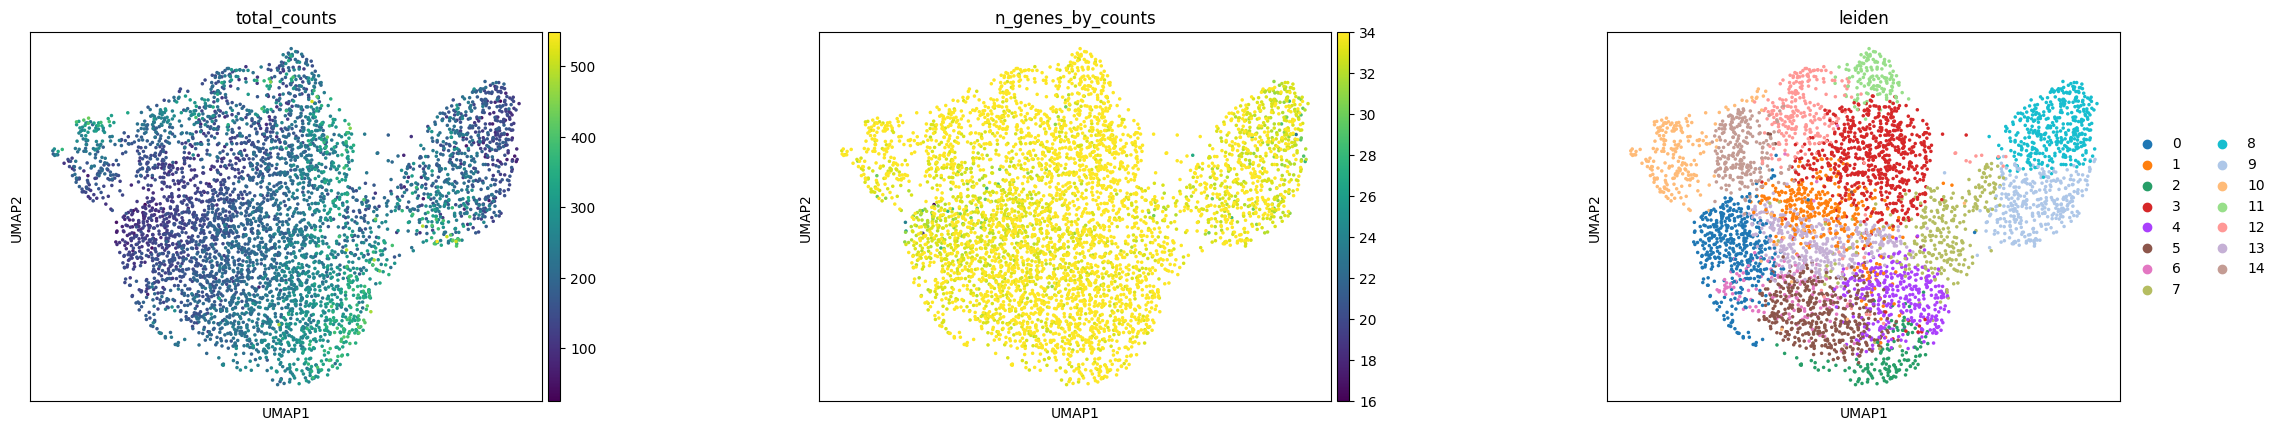

<Figure size 640x480 with 0 Axes>

Saved: umap_clusters_xenium.jpeg


In [10]:
sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden"],
    wspace=0.4,
)
plt.savefig("umap_clusters_xenium.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: umap_clusters_xenium.jpeg")

## Step 10: Visualize Clusters in Spatial Coordinates

Each dot is one individual cell at its exact physical position in the tissue, colored by its Leiden cluster. This is the key advantage of single-cell spatial data — we can see the spatial organization of different cell types.

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


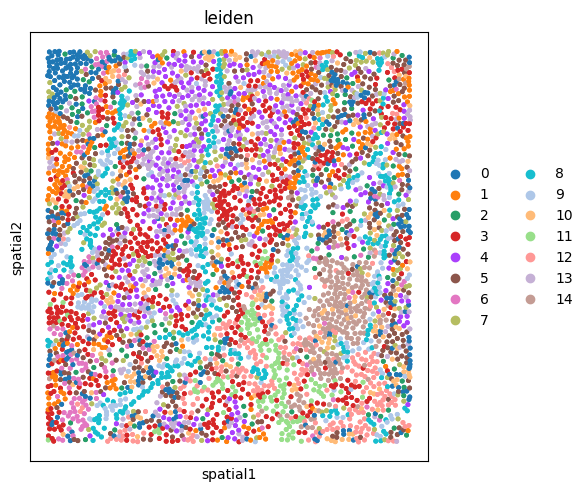

Saved: spatial_clusters.jpeg


In [11]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["leiden"],
    wspace=0.4,
)
plt.savefig("spatial_clusters.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_clusters.jpeg")

## Step 11: Build Spatial Neighborhood Graph

We build the spatial graph using **Delaunay triangulation**:
- `coord_type="generic"`: For single-cell data (not a regular grid like Visium)
- `delaunay=True`: Connects each cell to its geometrically nearest neighbors

This graph is the foundation for all spatial statistics below.

In [12]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
print("Spatial neighborhood graph built successfully!")

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Spatial neighborhood graph built successfully!


## Step 12: Compute Centrality Scores

Centrality scores describe the spatial role of each cluster:
- **Closeness centrality**: How centrally located is this cluster in the tissue?
- **Degree centrality**: How many connections to other cluster types?
- **Clustering coefficient**: How tightly do cells of this type group together?

In cancer tissue, these scores reveal which cell types occupy the tumor core vs the periphery.

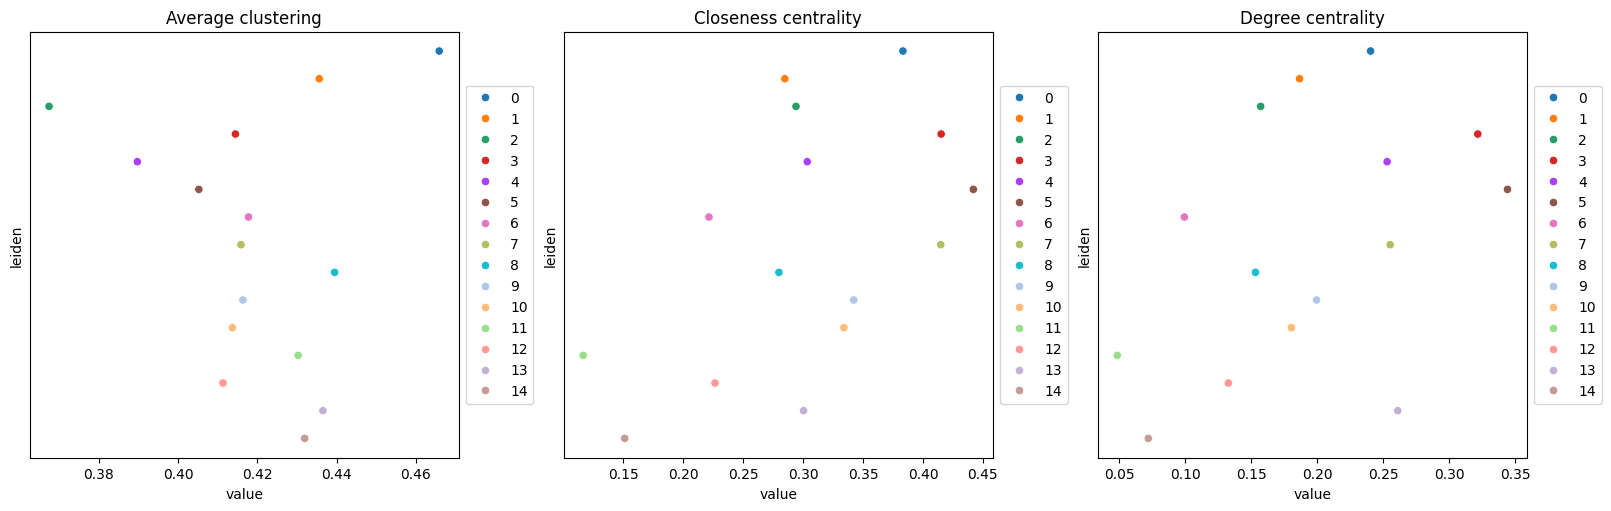

Saved: centrality_scores.jpeg


In [13]:
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))
plt.savefig("centrality_scores.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: centrality_scores.jpeg")

## Step 13: Compute Co-occurrence Probability

Co-occurrence measures how the probability of finding one cluster changes as you move away from another cluster:
- Score > 1: Clusters co-occur more than expected by chance
- Score = 1: No spatial relationship (random)
- Score < 1: Clusters avoid each other

We subsample 50% of cells to speed up computation.

Subsampled to 2334 cells
Plotting co-occurrence from cluster: 0


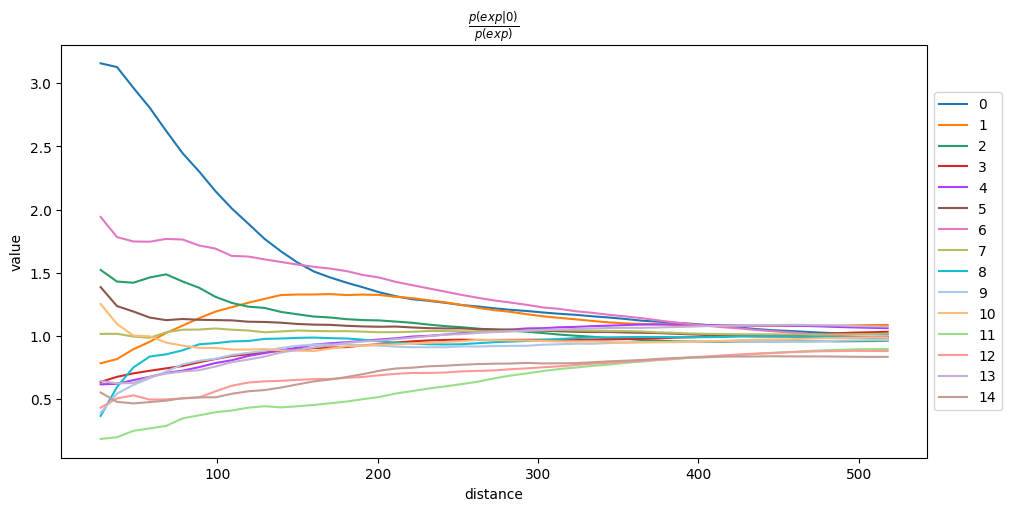

Saved: co_occurrence.jpeg


In [14]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)
print(f"Subsampled to {adata_subsample.n_obs} cells")

sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)

source_cluster = adata_subsample.obs["leiden"].cat.categories[0]
print(f"Plotting co-occurrence from cluster: {source_cluster}")

sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters=source_cluster,
    figsize=(10, 5),
)
plt.savefig("co_occurrence.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: co_occurrence.jpeg")

## Step 14: Neighborhood Enrichment Analysis

Which cell type clusters tend to be physically adjacent to each other?

- High positive score = these cell types prefer to be neighbors (enriched)
- High negative score = these cell types avoid each other (depleted)

Very useful in cancer biology to understand how tumor cells interact with immune cells.

  0%|          | 0/1000 [00:00<?, ?/s]

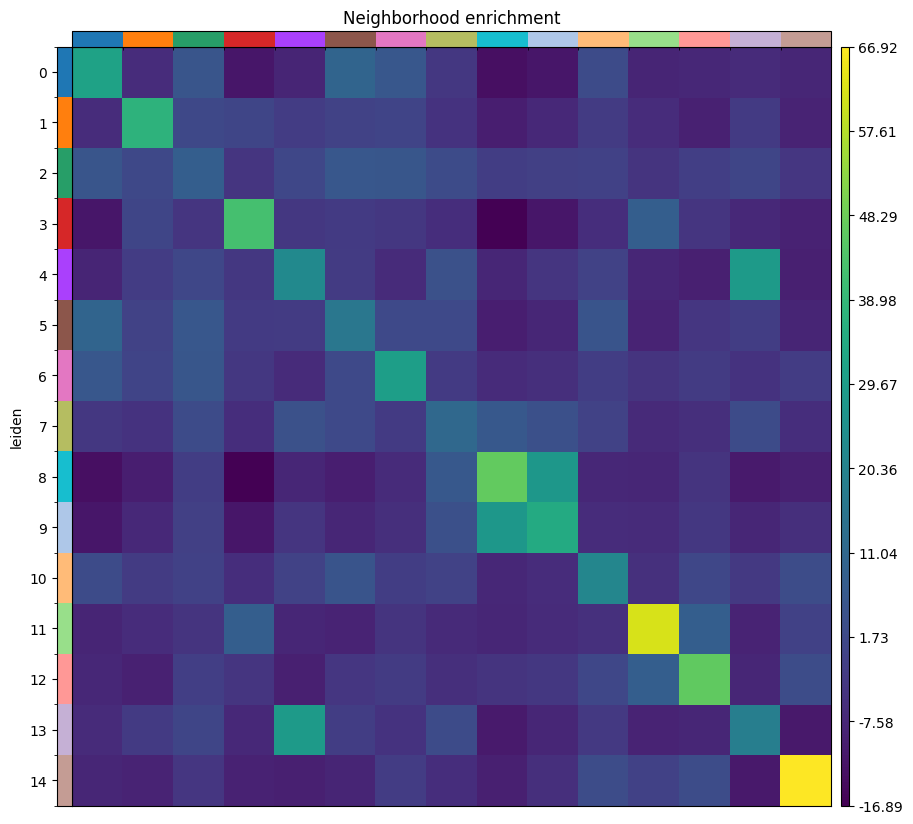

Saved: neighborhood_enrichment_xenium.jpeg


In [15]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment",
)
plt.savefig("neighborhood_enrichment_xenium.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: neighborhood_enrichment_xenium.jpeg")

## Step 15: Moran's I — Spatially Variable Genes

Moran's I measures whether a gene/marker's expression is spatially organized:
- **Close to +1**: Spatially clustered — nearby cells have similar expression
- **Close to 0**: Random — no spatial pattern

Genes with high Moran's I are spatially variable genes that mark specific tissue domains.

In [16]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)

sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

print("Top 10 spatially variable genes (Moran's I):")
adata_subsample.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

Top 10 spatially variable genes (Moran's I):


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
3521227Gd155Di Slug,0.683577,0.0,0.000146,0.0,0.009901,0.000452,0.0,0.0,0.009901
234832Lu175Di panCyto,0.535812,0.0,0.000146,0.0,0.009901,0.000251,0.0,0.0,0.009901
346876Sm147Di Keratin,0.511299,0.0,0.000146,0.0,0.009901,0.000204,0.0,0.0,0.009901
1031747Er167Di ECadhe,0.504987,0.0,0.000146,0.0,0.009901,0.000198,0.0,0.0,0.009901
77877Nd146Di CD68,0.474309,0.0,0.000146,0.0,0.009901,0.000203,0.0,0.0,0.009901
1921755Sm149Di Vimenti,0.438962,0.0,0.000146,0.0,0.009901,0.000177,0.0,0.0,0.009901
6967Gd160Di CD44,0.423339,0.0,0.000146,0.0,0.009901,0.000211,0.0,0.0,0.009901
98922Yb174Di Cytoker,0.396534,0.0,0.000146,0.0,0.009901,0.000229,0.0,0.0,0.009901
174864Nd148Di SMA,0.393915,0.0,0.000146,0.0,0.009901,0.000153,0.0,0.0,0.009901
3281668Nd142Di Fibrone,0.355066,0.0,0.000146,0.0,0.009901,0.000202,0.0,0.0,0.009901


## Step 16: Visualize Top Spatially Variable Genes

We visualize the top spatially variable genes from Moran's I in the tissue. These should show clear spatial patterns — concentrated in specific regions rather than uniformly distributed.

Top spatially variable genes: ['3521227Gd155Di Slug', '234832Lu175Di panCyto']


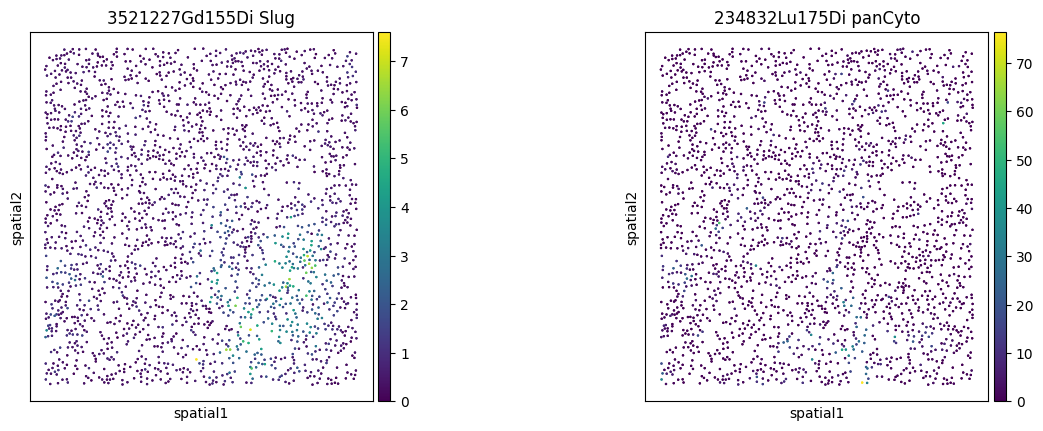

Saved: spatially_variable_genes.jpeg


In [17]:
top_genes = adata_subsample.uns["moranI"].head(2).index.tolist()
print(f"Top spatially variable genes: {top_genes}")

sq.pl.spatial_scatter(
    adata_subsample,
    color=top_genes,
    shape=None,
    size=2,
    img=False,
)
plt.savefig("spatially_variable_genes.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatially_variable_genes.jpeg")